In [1]:
import numpy as np
import sympy as sp
from jetgp.full_ddegp.ddegp import ddegp
import jetgp.utils as utils
from scipy.stats import qmc
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm

/home/sam/anaconda3/envs/pyoti_2/lib/python3.9/site-packages/scikits/__init__.py:1: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__('pkg_resources').declare_namespace(__name__)


In [2]:
n_order = 1
n_bases = 2
num_training_pts = 16
domain_bounds = ((-5.0, 10.0), (0.0, 15.0))
test_grid_resolution = 50

# Global set of directional rays
rays = np.array([
    [np.cos(np.pi/4), np.cos(np.pi/2), np.cos(3*np.pi/4)],
    [np.sin(np.pi/4), np.sin(np.pi/2), np.sin(3*np.pi/4)]
])

normalize_data = True
kernel = "SE"
kernel_type = "anisotropic"
random_seed = 1
np.random.seed(random_seed)

print("Configuration complete!")
print(f"Number of training points: {num_training_pts}")
print(f"Number of directional rays: {rays.shape[1]}")
print(f"Ray directions:")
for i in range(rays.shape[1]):
    angle_deg = np.arctan2(rays[1, i], rays[0, i]) * 180 / np.pi
    print(f"  Ray {i+1}: [{rays[0, i]:+.4f}, {rays[1, i]:+.4f}] (angle: {angle_deg:.1f}°)")

Configuration complete!
Number of training points: 16
Number of directional rays: 3
Ray directions:
  Ray 1: [+0.7071, +0.7071] (angle: 45.0°)
  Ray 2: [+0.0000, +1.0000] (angle: 90.0°)
  Ray 3: [-0.7071, +0.7071] (angle: 135.0°)


In [3]:
def branin_function(X, alg=np):
    """2D Branin function - a common benchmark for optimization."""
    x1, x2 = X[:, 0], X[:, 1]
    a, b, c, r, s, t = 1.0, 5.1/(4.0*np.pi**2), 5.0/np.pi, 6.0, 10.0, 1.0/(8.0*np.pi)
    return a * (x2 - b*x1**2 + c*x1 - r)**2 + s*(1 - t)*alg.cos(x1) + s

# Define symbolic version for derivatives
x1_sym, x2_sym = sp.symbols('x1 x2')
a, b, c, r, s, t = 1.0, 5.1/(4.0*sp.pi**2), 5.0/sp.pi, 6.0, 10.0, 1.0/(8.0*sp.pi)
f_sym = a * (x2_sym - b*x1_sym**2 + c*x1_sym - r)**2 + s*(1 - t)*sp.cos(x1_sym) + s

# Compute gradients symbolically
grad_x1 = sp.diff(f_sym, x1_sym)
grad_x2 = sp.diff(f_sym, x2_sym)

# Convert to NumPy functions
f_func = sp.lambdify([x1_sym, x2_sym], f_sym, 'numpy')
grad_x1_func = sp.lambdify([x1_sym, x2_sym], grad_x1, 'numpy')
grad_x2_func = sp.lambdify([x1_sym, x2_sym], grad_x2, 'numpy')

print("Branin function and symbolic derivatives defined!")

Branin function and symbolic derivatives defined!


In [4]:
# Latin Hypercube Sampling for training points
sampler = qmc.LatinHypercube(d=n_bases, seed=random_seed)
unit_samples = sampler.random(n=num_training_pts)
X_train = qmc.scale(unit_samples, [b[0] for b in domain_bounds], [b[1] for b in domain_bounds])

# Compute function values
y_func = f_func(X_train[:, 0], X_train[:, 1]).reshape(-1, 1)

# Compute coordinate-aligned gradients
grad_x1_vals = grad_x1_func(X_train[:, 0], X_train[:, 1]).reshape(-1, 1)
grad_x2_vals = grad_x2_func(X_train[:, 0], X_train[:, 1]).reshape(-1, 1)

# Compute directional derivatives using the chain rule
# For each ray: d_ray = grad_x1 * ray[0] + grad_x2 * ray[1]
directional_derivs = []
for i in range(rays.shape[1]):
    ray_direction = rays[:, i]
    dir_deriv = (grad_x1_vals * ray_direction[0] +
                 grad_x2_vals * ray_direction[1])
    directional_derivs.append(dir_deriv)

# Package training data
y_train_list = [y_func] + directional_derivs
der_indices = [[[[1, 1]], [[2, 1]], [[3, 1]]]]

print(f"Training data generated!")
print(f"X_train shape: {X_train.shape}")
print(f"Function values shape: {y_func.shape}")
print(f"Number of directional derivative arrays: {len(directional_derivs)}")

Training data generated!
X_train shape: (16, 2)
Function values shape: (16, 1)
Number of directional derivative arrays: 3


In [5]:
# Initialize the DDEGP model
gp_model = ddegp(
    X_train,
    y_train_list,
    n_order=n_order,
    der_indices=der_indices,
    rays=rays,
    normalize=normalize_data,
    kernel=kernel,
    kernel_type=kernel_type
)

print("DDEGP model initialized!")
print("Optimizing hyperparameters...")

# Optimize hyperparameters
params = gp_model.optimize_hyperparameters(
    optimizer='pso',
    pop_size=200,
    n_generations=15,
    local_opt_every=None,
    debug=False
)

print("Optimization complete!")
print(f"Optimized parameters: {params}")

DDEGP model initialized!
Optimizing hyperparameters...


Stopping: maximum iterations reached --> 15
Optimization complete!
Optimized parameters: [-0.02596297 -0.89539419  1.35052575 -6.9867352 ]


In [6]:
# Create dense test grid
x_lin = np.linspace(domain_bounds[0][0], domain_bounds[0][1], test_grid_resolution)
y_lin = np.linspace(domain_bounds[1][0], domain_bounds[1][1], test_grid_resolution)
X1_grid, X2_grid = np.meshgrid(x_lin, y_lin)
X_test = np.column_stack([X1_grid.ravel(), X2_grid.ravel()])

print(f"Test grid: {test_grid_resolution}×{test_grid_resolution} = {len(X_test)} points")

# Predict on test grid
y_pred = gp_model.predict(X_test, params, calc_cov=False, return_deriv=False)

# Compute ground truth and error
y_true = branin_function(X_test, alg=np)
nrmse = utils.nrmse(y_true, y_pred)
abs_error = np.abs(y_true - y_pred)

print(f"\nModel Performance:")
print(f"  NRMSE: {nrmse:.6f}")
print(f"  Max absolute error: {abs_error.max():.6f}")
print(f"  Mean absolute error: {abs_error.mean():.6f}")

Test grid: 50×50 = 2500 points

Model Performance:
  NRMSE: 0.000910
  Max absolute error: 4.106575
  Mean absolute error: 0.064468


In [7]:
# ------------------------------------------------------------
# Verify function value interpolation at all training points
# ------------------------------------------------------------
y_func_values = y_train_list[0]  # Function values

# Predict at training points (function values only)
y_pred_train = gp_model.predict(X_train, params, calc_cov=False, return_deriv=False)

print("Function value interpolation errors:")
print("=" * 70)
for i in range(num_training_pts):
    error_abs = abs(y_pred_train[0, i] - y_func_values[i, 0])
    error_rel = error_abs / abs(y_func_values[i, 0]) if y_func_values[i, 0] != 0 else error_abs
    print(f"Point {i} (x1={X_train[i, 0]:.4f}, x2={X_train[i, 1]:.4f}): "
          f"Abs Error = {error_abs:.2e}, Rel Error = {error_rel:.2e}")

max_func_error = np.max(np.abs(y_pred_train.flatten() - y_func_values.flatten()))
print(f"\nMaximum absolute function value error: {max_func_error:.2e}")

# ------------------------------------------------------------
# Verify directional derivative interpolation
# ------------------------------------------------------------
print("\n" + "=" * 70)
print("Directional derivative interpolation verification:")
print("=" * 70)
print(f"Number of directional rays: {rays.shape[1]}")
print(f"Ray directions:")
for i in range(rays.shape[1]):
    angle_deg = np.arctan2(rays[1, i], rays[0, i]) * 180 / np.pi
    print(f"  Ray {i+1}: [{rays[0, i]:+.4f}, {rays[1, i]:+.4f}] (angle: {angle_deg:.1f}°)")
print("=" * 70)

# Predict with derivatives - returns concatenated vector [func_vals, deriv1_vals, deriv2_vals, deriv3_vals]
y_pred_with_derivs = gp_model.predict(X_train, params, calc_cov=False, return_deriv=True)

print(f"\nPrediction with derivatives shape: {y_pred_with_derivs.shape}")
print(f"Expected: function values ({num_training_pts}) + 3 rays × {num_training_pts} = {num_training_pts * 4}")

# Extract predicted values from concatenated vector
# Format: [func_0, func_1, ..., func_15, ray1_0, ray1_1, ..., ray1_15, ray2_0, ..., ray2_15, ray3_0, ..., ray3_15]
start_idx = 0
pred_func_vals = y_pred_with_derivs[start_idx:start_idx + num_training_pts]
start_idx += num_training_pts

pred_deriv_ray1 = y_pred_with_derivs[start_idx:start_idx + num_training_pts]
start_idx += num_training_pts

pred_deriv_ray2 = y_pred_with_derivs[start_idx:start_idx + num_training_pts]
start_idx += num_training_pts

pred_deriv_ray3 = y_pred_with_derivs[start_idx:start_idx + num_training_pts]

# Extract analytic derivatives from training data
analytic_deriv_ray1 = y_train_list[1]
analytic_deriv_ray2 = y_train_list[2]
analytic_deriv_ray3 = y_train_list[3]

# Verify each ray's directional derivatives
pred_derivs = [pred_deriv_ray1, pred_deriv_ray2, pred_deriv_ray3]
analytic_derivs = [analytic_deriv_ray1, analytic_deriv_ray2, analytic_deriv_ray3]

for ray_idx in range(rays.shape[1]):
    print(f"\n{'-'*70}")
    print(f"Ray {ray_idx + 1} - Direction: [{rays[0, ray_idx]:+.4f}, {rays[1, ray_idx]:+.4f}]")
    print(f"{'-'*70}")

    pred_deriv = pred_derivs[ray_idx]
    analytic_deriv = analytic_derivs[ray_idx]

    for i in range(num_training_pts):
        error_abs = abs(pred_deriv[i, 0] - analytic_deriv[i, 0])
        error_rel = error_abs / abs(analytic_deriv[i, 0]) if analytic_deriv[i, 0] != 0 else error_abs

        print(f"Point {i} (x1={X_train[i, 0]:.4f}, x2={X_train[i, 1]:.4f}):")
        print(f"  Analytic: {analytic_deriv[i, 0]:+.6f}, Predicted: {pred_deriv[i, 0]:+.6f}")
        print(f"  Abs Error: {error_abs:.2e}, Rel Error: {error_rel:.2e}")

    max_deriv_error = np.max(np.abs(pred_deriv.flatten() - analytic_deriv.flatten()))
    print(f"\nMaximum absolute error for Ray {ray_idx + 1}: {max_deriv_error:.2e}")

print("\n" + "=" * 70)
print("Interpolation verification complete!")
print("Relative errors should be close to machine precision (< 1e-6)")
print("\n" + "=" * 70)
print("SUMMARY:")
print(f"  - Function values: enforced at all {num_training_pts} training points")
print(f"  - Directional derivatives: {rays.shape[1]} rays at each training point")
print(f"  - Total constraints: {num_training_pts} function values + "
      f"{num_training_pts * rays.shape[1]} directional derivatives")
print(f"  - Prediction vector structure: [func_vals ({num_training_pts}), "
      f"ray1 ({num_training_pts}), ray2 ({num_training_pts}), ray3 ({num_training_pts})]")
print(f"  - Ray 1 direction: [{rays[0, 0]:+.4f}, {rays[1, 0]:+.4f}] "
      f"(angle: {np.arctan2(rays[1, 0], rays[0, 0]) * 180 / np.pi:.1f}°)")
print(f"  - Ray 2 direction: [{rays[0, 1]:+.4f}, {rays[1, 1]:+.4f}] "
      f"(angle: {np.arctan2(rays[1, 1], rays[0, 1]) * 180 / np.pi:.1f}°)")
print(f"  - Ray 3 direction: [{rays[0, 2]:+.4f}, {rays[1, 2]:+.4f}] "
      f"(angle: {np.arctan2(rays[1, 2], rays[0, 2]) * 180 / np.pi:.1f}°)")
print("=" * 70)

Function value interpolation errors:
Point 0 (x1=2.9577, x2=2.8589): Abs Error = 6.09e-07, Rel Error = 8.12e-07
Point 1 (x1=-4.1976, x2=12.2356): Abs Error = 2.43e-07, Rel Error = 1.91e-08
Point 2 (x1=8.7702, x2=8.0406): Abs Error = 3.26e-07, Rel Error = 8.32e-09
Point 3 (x1=9.2240, x2=13.6789): Abs Error = 2.93e-08, Rel Error = 2.26e-10
Point 4 (x1=3.8598, x2=5.5992): Abs Error = 6.52e-07, Rel Error = 3.76e-08
Point 5 (x1=-2.8939, x2=10.7455): Abs Error = 7.55e-07, Rel Error = 4.78e-07
Point 6 (x1=5.9409, x2=5.8233): Abs Error = 1.43e-06, Rel Error = 3.45e-08
Point 7 (x1=6.9033, x2=2.3873): Abs Error = 9.35e-07, Rel Error = 4.85e-08
Point 8 (x1=0.4993, x2=0.5596): Abs Error = 1.12e-06, Rel Error = 2.79e-08
Point 9 (x1=2.3093, x2=4.4416): Abs Error = 5.30e-07, Rel Error = 9.51e-08
Point 10 (x1=-1.9535, x2=1.6121): Abs Error = 7.42e-07, Rel Error = 1.06e-08
Point 11 (x1=4.8576, x2=6.5806): Abs Error = 3.32e-07, Rel Error = 8.50e-09
Point 12 (x1=0.6609, x2=8.6955): Abs Error = 1.87e-06, 

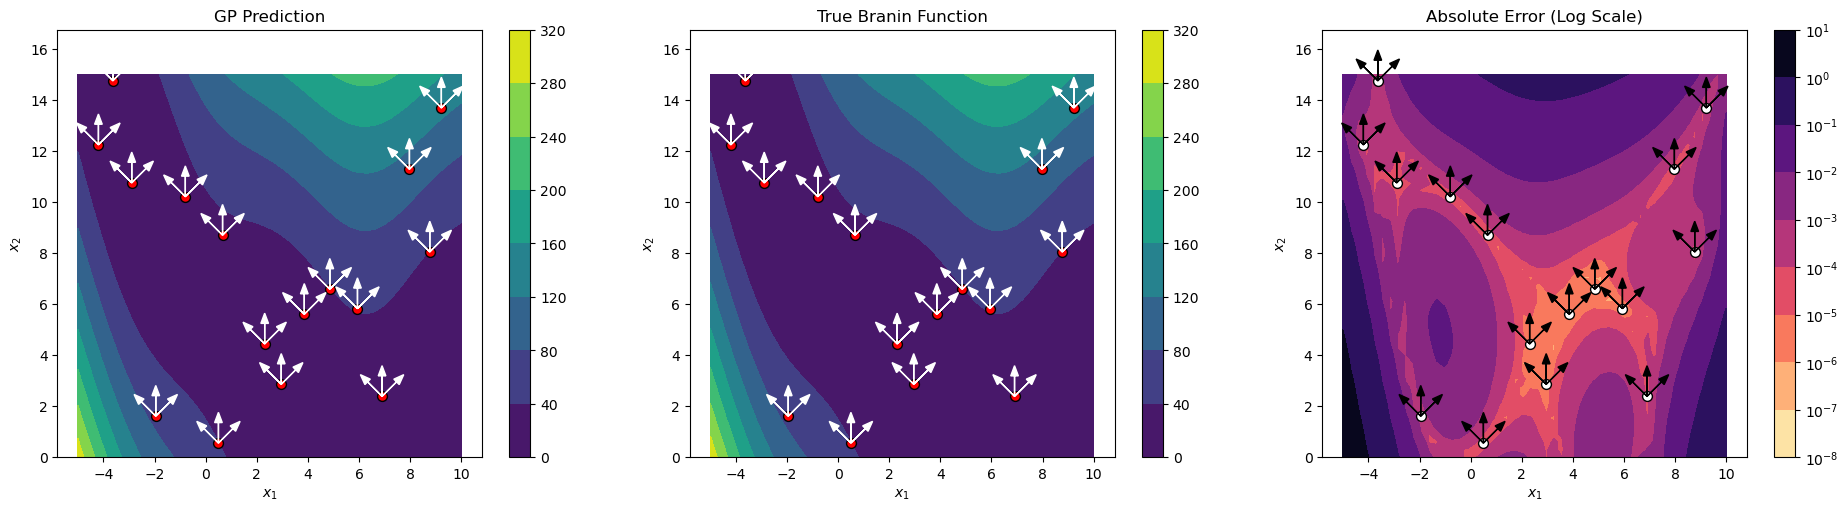


Final NRMSE: 0.000910


In [8]:
# Prepare visualization data
gp_map = y_pred.reshape(X1_grid.shape)
true_map = y_true.reshape(X1_grid.shape)
abs_err = np.abs(gp_map - true_map)
abs_err_clipped = np.clip(abs_err, 1e-8, None)

# Create three-panel figure
fig, axs = plt.subplots(1, 3, figsize=(19, 5), constrained_layout=True)

# GP Prediction
cf1 = axs[0].contourf(X1_grid, X2_grid, gp_map, cmap='viridis')
fig.colorbar(cf1, ax=axs[0])
axs[0].scatter(X_train[:, 0], X_train[:, 1], c='red', s=50, edgecolors='black')
axs[0].set_title("GP Prediction")

# True Function
cf2 = axs[1].contourf(X1_grid, X2_grid, true_map, cmap='viridis')
fig.colorbar(cf2, ax=axs[1])
axs[1].scatter(X_train[:, 0], X_train[:, 1], c='red', s=50, edgecolors='black')
axs[1].set_title("True Branin Function")

# Absolute Error
cf3 = axs[2].contourf(X1_grid, X2_grid, abs_err_clipped,
                       norm=LogNorm(), cmap='magma_r')
fig.colorbar(cf3, ax=axs[2])
axs[2].scatter(X_train[:, 0], X_train[:, 1], c='white', s=50, edgecolors='black')
axs[2].set_title("Absolute Error (Log Scale)")

# Draw directional rays at each training point
ray_length = 0.8
for ax, color in zip(axs, ['white', 'white', 'black']):
    for pt in X_train:
        for i in range(rays.shape[1]):
            direction = rays[:, i]
            ax.arrow(pt[0], pt[1], direction[0]*ray_length,
                     direction[1]*ray_length, head_width=0.3, head_length=0.4,
                     fc=color, ec=color)

for ax in axs:
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_aspect("equal")

plt.show()

print(f"\nFinal NRMSE: {nrmse:.6f}")